<a href="https://colab.research.google.com/github/George2477/ML-/blob/main/NLP_%D0%9B%D0%A0_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 БИЗНЕС-МЕТРИКИ:
•  Экономия: $-76,526 / мес
•  Авто-обработка: 51.1% отзывов
•  Защита бренда: 88.6 / 100
 ТЕХНИЧЕСКИЕ МЕТРИКИ МОДЕЛИ
• Accuracy:           0.8890
• Precision (Точность): 0.8986
• Recall (Полнота):   0.8773
• F1-Score:           0.8878
• Specificity:        0.9007
• AUC-ROC:            0.9601
• FOR (Пропуски):     0.1202
• FP/TN Ratio:        0.1103

 Матрица ошибок [TN, FP, FN, TP]: 5467 603 747 5341


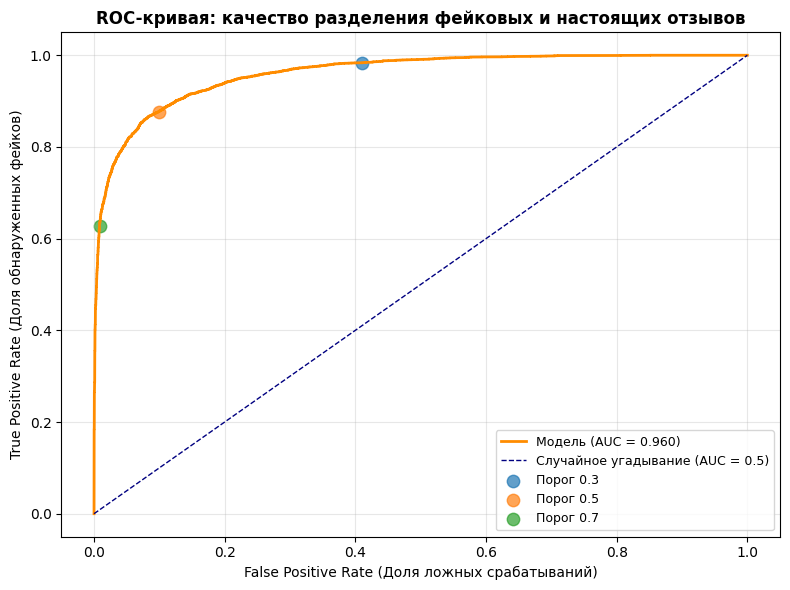

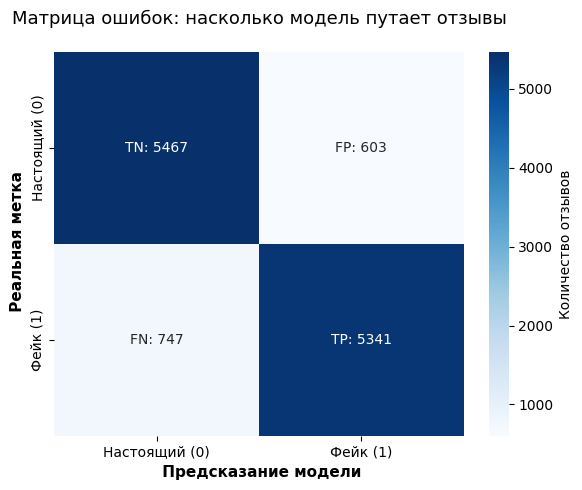

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
CSV_PATH = 'fake_reviews_dataset.csv'

df = pd.read_csv(CSV_PATH, header=0)

df = df.dropna(subset=['text', 'label'])

texts  = df['text'].astype(str).values
labels = df['label'].values

if not np.issubdtype(labels.dtype, np.number):
    labels = np.array([1 if str(x).lower() in ['fake', 'spam', '1', 'yes'] else 0 for x in labels])

# =============================================================================
# 2. РАЗДЕЛЕНИЕ НА ОБУЧЕНИЕ И ТЕСТ
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

# =============================================================================
# 3. ВЕКТОРИЗАЦИЯ TF-IDF (Превращение текста в числа)
# =============================================================================
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    strip_accents='unicode',
    token_pattern=r'(?u)\b\w\w+\b'
)

# fit_transform: изучает словарь на train-данных и преобразует их в матрицу
X_train_vec = vectorizer.fit_transform(X_train)
# transform: применяет ВЫУЧЕННЫЙ словарь к test-данных (fit вызывать НЕЛЬЗЯ, иначе будет утечка данных!)
X_test_vec  = vectorizer.transform(X_test)

# =============================================================================
# 4. ОБУЧЕНИЕ МОДЕЛЕЙ
# =============================================================================
# --- Наивный Байес (MultinomialNB) ---
nb = MultinomialNB(
    alpha=0.5
)
nb.fit(X_train_vec, y_train)

# --- Градиентный Бустинг (GradientBoostingClassifier) ---
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_train_vec, y_train)

# =============================================================================
# 5. ОБЪЕДИНЕНИЕ ПРЕДСКАЗАНИЙ (АНСАМБЛЬ)
# =============================================================================
#  Берём второй столбец → вероятность фейка
prob_nb = nb.predict_proba(X_test_vec)[:, 1]
prob_gb = gb.predict_proba(X_test_vec)[:, 1]

# Взвешенное среднее: Бустинг обычно точнее (60%), Байес лучше ловит очевидные эмоциональные маркеры (40%)
prob_ensemble = 0.6 * prob_gb + 0.4 * prob_nb

# Порог 0.5: если вероятность >= 0.5 → ставим 1 (фейк), иначе 0 (настоящий)
y_pred = (prob_ensemble >= 0.5).astype(int)

# =============================================================================
# 6. РАСЧЁТ ТЕХНИЧЕСКИХ МЕТРИК (строго по вашему ТЗ)
# =============================================================================
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy    = (tp + tn) / len(y_test)
precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
for_rate    = fn / (fn + tn) if (fn + tn) > 0 else 0
fp_tn_ratio = fp / tn if tn > 0 else 0
auc_roc     = roc_auc_score(y_test, prob_ensemble)

# =============================================================================
# 7. БИЗНЕС-МЕТРИКИ
# =============================================================================
# Параметры (настройте под ваш проект)
COST_MANUAL = 0.50        # $ за ручную проверку 1 отзыва
COST_FAKE_MISS = 15.00    # $ убытка от пропущенного фейка
COST_FALSE_ALARM = 2.00   # $ затрат на ложное обвинение
MONTHLY_VOLUME = 100000   # отзывов в месяц

# 1. 💰 Экономия в месяц ($)
cost_without = MONTHLY_VOLUME * COST_MANUAL
cost_with = ((fp + tp) * COST_MANUAL + fn * COST_FAKE_MISS + fp * COST_FALSE_ALARM) * (MONTHLY_VOLUME / len(y_test))
monthly_savings = cost_without - cost_with

# 2. 👥 % отзывов без ручной проверки
review_reduction_pct = ((tn + fn) / len(y_test)) * 100

# 3. 🛡️ Индекс защиты бренда (0-100)
brand_score = (0.4 * precision + 0.6 * recall) * 100

# Вывод только 3 метрик
print("\n БИЗНЕС-МЕТРИКИ:")
print(f"•  Экономия: ${monthly_savings:,.0f} / мес")
print(f"•  Авто-обработка: {review_reduction_pct:.1f}% отзывов")
print(f"•  Защита бренда: {brand_score:.1f} / 100")

# =============================================================================
# 8. ВЫВОД ВСЕХ МЕТРИК
# =============================================================================
print("=" * 60)
print(" ТЕХНИЧЕСКИЕ МЕТРИКИ МОДЕЛИ")
print("=" * 60)
print(f"• Accuracy:           {accuracy:.4f}")
print(f"• Precision (Точность): {precision:.4f}")
print(f"• Recall (Полнота):   {recall:.4f}")
print(f"• F1-Score:           {f1:.4f}")
print(f"• Specificity:        {specificity:.4f}")
print(f"• AUC-ROC:            {auc_roc:.4f}")
print(f"• FOR (Пропуски):     {for_rate:.4f}")
print(f"• FP/TN Ratio:        {fp_tn_ratio:.4f}")
print(f"\n Матрица ошибок [TN, FP, FN, TP]: {tn} {fp} {fn} {tp}")

# =============================================================================
# 9. ВИЗУАЛИЗАЦИЯ: ROC-кривая
# =============================================================================
# roc_curve возвращает: FPR (False Positive Rate), TPR (True Positive Rate), пороги
fpr, tpr, thresholds = roc_curve(y_test, prob_ensemble)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Модель (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Случайное угадывание (AUC = 0.5)')

# Добавляем точки для ключевых порогов (0.3, 0.5, 0.7) для интерпретации
for thresh in [0.3, 0.5, 0.7]:
    pred_temp = (prob_ensemble >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred_temp).ravel()
    fpr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    tpr_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    plt.scatter(fpr_t, tpr_t, s=80, alpha=0.7, label=f'Порог {thresh}')

plt.xlabel('False Positive Rate (Доля ложных срабатываний)', fontsize=10)
plt.ylabel('True Positive Rate (Доля обнаруженных фейков)', fontsize=10)
plt.title('ROC-кривая: качество разделения фейковых и настоящих отзывов', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# 10. ВИЗУАЛИЗАЦИЯ: Матрица ошибок (Confusion Matrix)
# =============================================================================
import seaborn as sns

# Создаём подписи для ячеек матрицы
labels = [[f"TN: {tn}", f"FP: {fp}"],
          [f"FN: {fn}", f"TP: {tp}"]]

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=labels,
            fmt='',
            cmap='Blues',
            xticklabels=['Настоящий (0)', 'Фейк (1)'],
            yticklabels=['Настоящий (0)', 'Фейк (1)'],
            cbar_kws={'label': 'Количество отзывов'})

plt.xlabel(' Предсказание модели', fontsize=11, fontweight='bold')
plt.ylabel(' Реальная метка', fontsize=11, fontweight='bold')
plt.title('Матрица ошибок: насколько модель путает отзывы', fontsize=13, pad=20)
plt.tight_layout()
plt.show()